# Water Flow Optimization

## Problem Description
#### Water scarcity and inefficient distribution arise from factors like overuse, population growth, and infrastructure inefficiencies. These challenges lead to wastage, inequitable access, and environmental stress, making water management a critical issue to address.
#### Water scarcity is a pressing global challenge, characterized by the lack of sufficient water resources to meet the demands of human populations, industries, and ecosystems. This problem affects billions of people and has far-reaching social, economic, and environmental consequences.

## Significance
#### Optimizing water flow ensures efficient resource utilization, reduces wastage, and promotes equitable distribution. Addressing this issue contributes to sustainability, cost savings, and improved quality of life for communities.

The water flow optimization problem involves the efficient distribution of a limited water supply to various demand points, taking into account:
- Multiple water sources
- Demand points with different priorities
- Flow path capacities
- Water leakage detection and mitigation


## Paradigm Used

- **Search**
The algorithm uses search to identify the most suitable paths for water distribution. Paths are explored and ranked by their capacities or potential to fulfill demand, employing techniques like insertion sort to prioritize options.

- **Decision**
Key decisions involve allocating water from sources to demand points based on priority and capacity. Decisions are adjusted dynamically in response to events like leakages, ensuring demands are met effectively.

- **Organization**
The data is structured into dictionaries and lists for sources, demand points, and paths, enabling systematic access and manipulation. Sorting mechanisms organize priorities and capacities for streamlined allocation.

- **Optimization**
Water distribution is optimized to maximize the satisfaction of demand within the constraints of capacity and source availability. Additional passes through unmet demands refine allocations to ensure minimal resource wastage



## Program Details

### Sources
```python
sources = {
    "Ludhiana": 500,  # Total available water in Million Liters
    "Mohali": 450,
    "Patiala": 400,
    "Chandigarh": 550,
    
}
```

### Demand Points
```python
demand_points = {
    "Kambala": {"demand": 100, "priority": 1, "received": 0},
    "Sector 15": {"demand": 80, "priority": 2, "received": 0},
    "Old City": {"demand": 120, "priority": 3, "received": 0},
    "Rajpura": {"demand": 150, "priority": 1, "received": 0},
    "Sangrur": {"demand": 60, "priority": 3, "received": 0},
    "IT City": {"demand": 70, "priority": 1, "received": 0},
    "Manauli": {"demand": 70, "priority": 3, "received": 0},
    "Sector 65": {"demand": 75, "priority": 2, "received": 0},
}
```
#### Demands may change due to natural calamities, political and social effects and other factors


### Flow Paths
```python
flow_paths = {
    "Ludhiana to Kambala": {"capacity": 100, "flow": 0, "excluded": False},
    "Mohali to Kambala": {"capacity": 120, "flow": 0, "excluded": False},
    "Mohali to Sector 15": {"capacity": 100, "flow": 0, "excluded": False},
    "Chandigarh to Sector 15": {"capacity": 80, "flow": 0, "excluded": False},
    "Patiala to Old City": {"capacity": 200, "flow": 0, "excluded": False},
    "Chandigarh to Old City": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Rajpura": {"capacity": 200, "flow": 0, "excluded": False},
    "Patiala to Rajpura": {"capacity": 250, "flow": 0, "excluded": False},
    "Mohali to Sangrur": {"capacity": 240, "flow": 0, "excluded": False},
    "Patiala to Sangrur": {"capacity": 130, "flow": 0, "excluded": False},
    "Mohali to IT City": {"capacity": 260, "flow": 0, "excluded": False},
    "Chandigarh to IT City": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Manauli": {"capacity": 140, "flow": 0, "excluded": False},
    "Mohali to Manauli": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Sector 65": {"capacity": 90, "flow": 0, "excluded": False},
    "Mohali to Sector 65": {"capacity": 240, "flow": 0, "excluded": False},
}

```
#### Capacity: Based on the size and strength of the water pipes or channels



---

## Functions Explained

### 1. **`allocate_initial_flow()`**
   - **Purpose**: Allocates the initial flow of water from sources to demand points based on their capacities.
   - **Working**:
     - Iterates over all flow paths.
     - For each path, it checks if the path is not excluded due to leakage.
     - Determines the water allocation based on the minimum of available water at the source, the path’s capacity, and the demand at the destination.
     - Updates the sources’ water and the demand points’ received water.
   - **Logic**:
     - For each flow path:
       - Check if it’s not excluded.
       - Calculate the allocation by considering the path’s capacity and the remaining demand.
       - Update the source’s available water and the demand point’s received water.
     - Captures the state before any changes are made for potential recovery in case of a detected leak.
   - **Limitations**:
     - Assumes there’s no leakage initially.

### 2. **`check_and_fix_leakage()`**
   - **Purpose**: Detects any leakage and redistributes water to handle the deficiency.
   - **Working**:
     - Iterates over all flow paths.
     - For each path, it asks the user for the actual amount of water received.
     - If the received water is less than the allocated flow, a leakage is detected.
     - Reverts the changes made for that path and marks it as excluded.
     - allocate the remaining demand through other available paths.
   - **Logic**:
     - Compares the received water with the allocated flow.
     - If less, detects a leak, reverts changes, and marks the path as excluded.
     -  allocate the remaining demand through alternative paths.
   - **Limitations**:
     - The program relies on user input for detecting leaks, which might not always reflect real-world conditions accurately.

### **`redistribute_flow in check_and_fix_leakage()`**
   - **Purpose**: Redistributes water to a demand point if there is an unmet demand due to leakage.
   - **Working**:
     - Calculates the remaining demand for the destination.
     - Iterates through all available paths leading to the destination.
     - Allocates water from alternative sources to cover the unmet demand.
     - Updates both the source’s available water and the demand point’s received water accordingly.
   - **Logic**:
     - Determines the remaining demand.
     - Iterates over paths leading to the destination.
     - Allocates water until the demand is met or no more feasible allocations are possible.
   - **Limitations**:
     - Assumes availability of alternative paths and sufficient water in alternative sources for redistribution.

### 4. **`insertion_sort(data, key)`**
   - **Purpose**: Sorts demand points by priority.
   - **Working**:
     - Converts the demand points dictionary into a list of items.
     - Uses the insertion sort algorithm to sort based on the specified priority key.
     - Returns the sorted list.
   - **Logic**:
     - Iterates through the list of demand points.
     - Compares and shifts items to sort them based on priority.
   - **Limitations**:
     - It is not efficient for very large datasets as insertion sort has a time complexity of O(n^2).

### 5. **`optimize_flow()`**
   - **Purpose**: Dynamically reallocates water to meet remaining demands.
   - **Working**:
     - Repeatedly calls `insertion_sort()` to sort demand points by priority.
     - Iterates over these sorted demand points.
     - Attempts to allocate water via all available, non-excluded paths.
     - Stops when no further allocation is possible.
   - **Logic**:
     - Checks each demand point’s received water against its total demand.
     - Uses the sorted list of demand points to find and meet the shortfall using the available paths.
   - **Limitations**:
     - Assumes sufficient capacity in all paths to meet the demand, which may not be the case in real-world scenarios.

### 6. **`is_objective_achieved()`**
   - **Purpose**: Checks if all demand points have received their required water.
   - **Working**:
     - Iterates through all demand points.
     - Compares the received water with the demand.
     - Returns `True` if all demands are met, otherwise `False`.
   - **Logic**:
     - Simple comparison for each demand point.
   - **Limitations**:
     - Does not consider any priority among demand points beyond what is initially set.
     - Does not account for external factors such as emergencies or political influences affecting water distribution.

---

## Simulation Process

1. Allocate initial water flow
2. Check and fix potential leakages
3. Optimize flow if objective not achieved
4. Print final distribution results


## Limitations of the Program in the Real World

1. **Limited Path Selection**:
   - The program only reallocates water through predefined paths and doesn’t consider dynamic infrastructure changes, emergencies, or other sudden demands that could arise in the real world.
   - In reality, alternative routes and dynamic adjustments are often required to manage unforeseen disruptions.

2. **Simplified Priority Handling**:
   - Demand priority is managed in a simplistic manner without considering varying impacts of demand points.
   - Real-world water allocation often involves complex negotiations, political, and socio-economic factors influencing priorities.

3. **Lack of Real-World Constraints**:
   - The program does not simulate other limitations such as budgetary constraints, environmental restrictions, or legal constraints on water use.
   - It assumes an infinite capacity in terms of the ability to meet all demands, which is rarely the case in practice.
   - So some constraints has to be applied here. 

This program provides a basic framework for water distribution but needs significant improvements for real-world application.


![Final Water Flow Optimization-2.png](<attachment:Final Water Flow Optimization-2.png>)
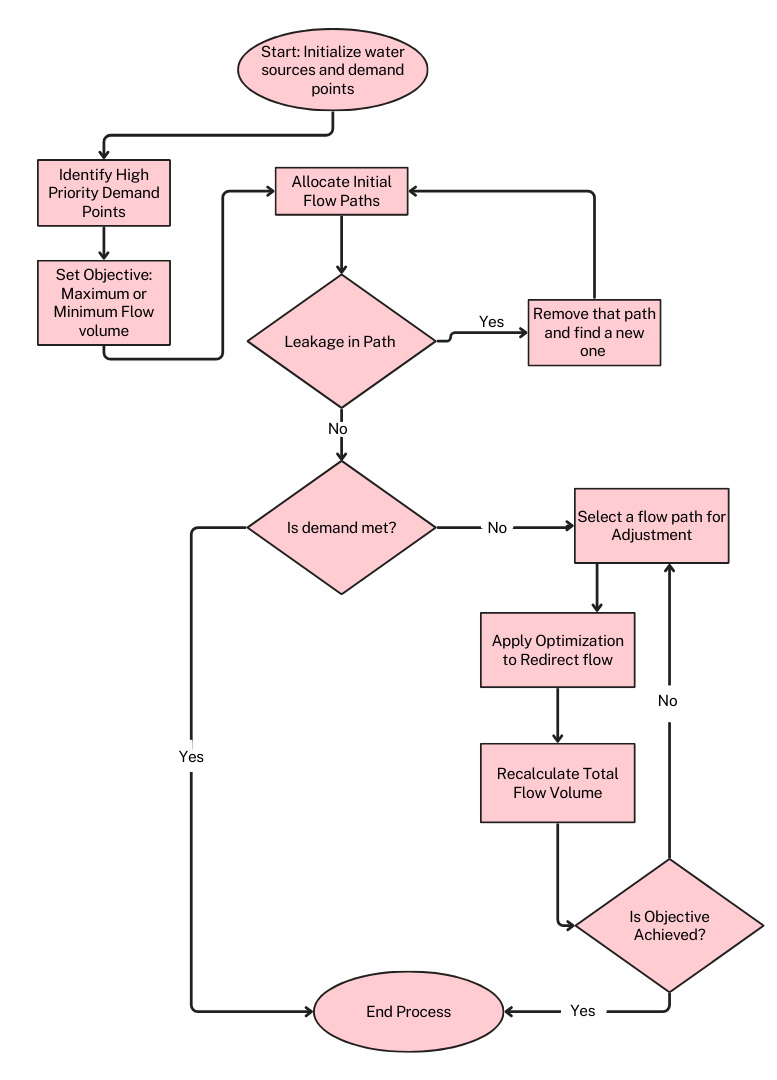
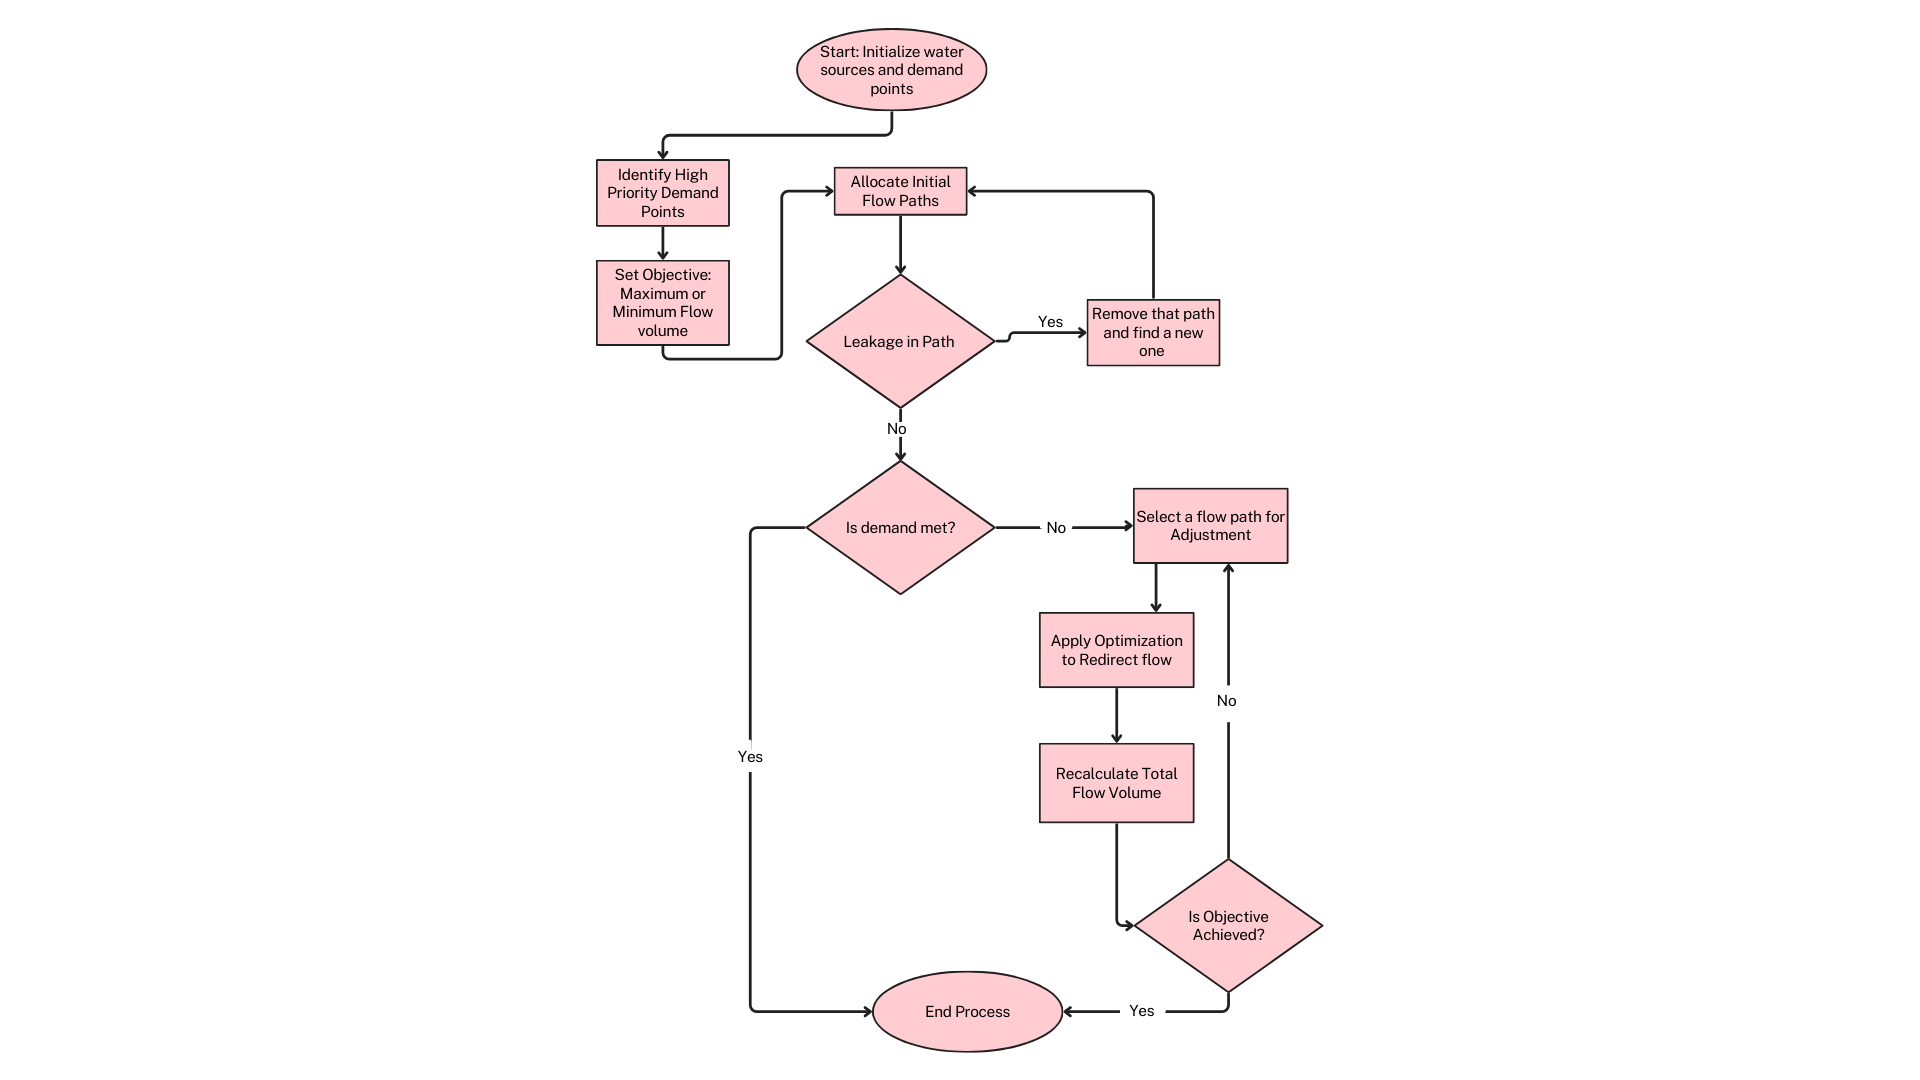

In [2]:
# Define the sources of water
sources = {
    "Ludhiana": 500,  # Total available water in Million Liters
    "Mohali": 450,
    "Patiala": 400,
    "Chandigarh": 550,
    "Rajpura": 200
}

# Define demand points with priority levels
# '1' indicates highest priority followed by 2 and so on
demand_points = {
    "Kambala": {"demand": 100, "priority": 1, "received": 0},
    "Sector 15": {"demand": 80, "priority": 2, "received": 0},
    "Old City": {"demand": 120, "priority": 3, "received": 0},
    "Rajpura": {"demand": 150, "priority": 1, "received": 0},
    "Sangrur": {"demand": 60, "priority": 3, "received": 0},
    "IT City": {"demand": 70, "priority": 1, "received": 0},
    "Manauli": {"demand": 70, "priority": 3, "received": 0},
    "Sector 65": {"demand": 75, "priority": 2, "received": 0},
    "Civil Hospital": {"demand": 10, "priority":1, "received": 0},
    "Mohan Colony": {"demand": 15, "priority":2, "received": 0}
}

# Create a copy of demand points to reset "received" during leakage handling
original_demand_points = {key: value.copy() for key, value in demand_points.items()}

# Define flow paths with capacities, excluded == True indicates leakage
flow_paths = {
    "Ludhiana to Kambala": {"capacity": 100, "flow": 0, "excluded": False},
    "Mohali to Kambala": {"capacity": 120, "flow": 0, "excluded": False},
    "Mohali to Sector 15": {"capacity": 100, "flow": 0, "excluded": False},
    "Chandigarh to Sector 15": {"capacity": 80, "flow": 0, "excluded": False},
    "Patiala to Old City": {"capacity": 200, "flow": 0, "excluded": False},
    "Chandigarh to Old City": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Rajpura": {"capacity": 200, "flow": 0, "excluded": False},
    "Patiala to Rajpura": {"capacity": 250, "flow": 0, "excluded": False},
    "Mohali to Sangrur": {"capacity": 240, "flow": 0, "excluded": False},
    "Patiala to Sangrur": {"capacity": 130, "flow": 0, "excluded": False},
    "Mohali to IT City": {"capacity": 260, "flow": 0, "excluded": False},
    "Chandigarh to IT City": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Manauli": {"capacity": 140, "flow": 0, "excluded": False},
    "Mohali to Manauli": {"capacity": 150, "flow": 0, "excluded": False},
    "Ludhiana to Sector 65": {"capacity": 90, "flow": 0, "excluded": False},
    "Mohali to Sector 65": {"capacity": 240, "flow": 0, "excluded": False},
    "Rajpura to Mohan Colony": {"capacity": 50, "flow": 0, "excluded": False},
    "Rajpura to Civil Hospital": {"capacity": 40, "flow": 0, "excluded": False},
}


# Function to sort demand points or paths using insertion sort

def insertion_sort(data, key, reverse=False):
    items = list(data)  # Assume data is a list of tuples
    for i in range(1, len(items)):
        current_item = items[i]
        j = i - 1
        while j >= 0 and ((key(items[j]) < key(current_item)) if reverse else (key(items[j]) > key(current_item))):
            items[j + 1] = items[j]
            j -= 1
        items[j + 1] = current_item
    return items



# Function to allocate initial flow to demand points based on the highest capacity paths
# Allocates one path only per unique demand point

def allocate_initial_flow():

    # Sort demand points by priority (ascending order, as 1 is the highest priority)
    sorted_demand_points = insertion_sort(demand_points.items(), lambda x: x[1]["priority"])

    for destination, details in sorted_demand_points:    # details contain demands, priority and received 
        remaining_demand = details["demand"] - details["received"]

        # Find all paths leading to the destination that are not excluded
        paths_to_destination = [
            (path, details) for path, details in flow_paths.items()
            if path.split(" to ")[1] == destination and not details["excluded"]
        ]

        # Sort paths by capacity in descending order using insertion sort
        paths_to_destination = insertion_sort(paths_to_destination, lambda x: x[1]["capacity"], reverse=True)

        # Allocate water to the destination using the sorted paths
        for path, details in paths_to_destination:
            if remaining_demand <= 0:
                break  # Stop if the demand is already met

            source, _ = path.split(" to ")    # path having source and destination 
            available = sources[source]
            allocation = min(available, details["capacity"], remaining_demand)
            if allocation > 0:
                flow_paths[path]["flow"] += allocation
                sources[source] -= allocation
                demand_points[destination]["received"] += allocation
                remaining_demand -= allocation


# Function to check and fix leakage, reallocating water only for leaked paths
def check_and_fix_leakage():
    confirmed_paths = set()  # Track paths that have been checked and confirmed
    confirmed_destinations = set()  # Track destinations that have fully met demand

    while True:
        leaked_paths = []
        for path, details in flow_paths.items():
            # checking if the path is not excluded(leaked) and not confirmed yet
            if details["flow"] > 0 and not details["excluded"] and path not in confirmed_paths:
                source, destination = path.split(" to ")

                # Skip checking destinations that already meet demand
                if destination in confirmed_destinations:
                    confirmed_paths.add(path)
                    continue

                # checking how much water is actually received through a particular path 
                received = int(input(f"How much water is actually received by {destination} through path '{path}'? "))
                if received < details["flow"]:  # Leakage detected
                    print(f"Leakage detected in path {path}. Marking it as excluded and redistributing water.")
                    flow_paths[path]["excluded"] = True
                    sources[source] += details["flow"]  # Revert allocation to the source
                    demand_points[destination]["received"] -= details["flow"]  # Revert allocation from the demand
                    leaked_paths.append(destination)
                    
                else:
                    confirmed_paths.add(path)  # Mark path as confirmed
                    if demand_points[destination]["received"] >= demand_points[destination]["demand"]:
                        confirmed_destinations.add(destination)  # Mark destination as satisfied

        if not leaked_paths:
            break  # Exit if no leaks detected

        # Reset demand points to original values for leaked destinations
        for destination in leaked_paths:
            demand_points[destination]["received"] = original_demand_points[destination]["received"]
            remaining_demand = demand_points[destination]["demand"] - demand_points[destination]["received"]

            # Find alternative paths for the destination
            paths_to_destination = [
                (path, details) for path, details in flow_paths.items()
                if path.split(" to ")[1] == destination and not details["excluded"]
            ]
            # Sort paths by capacity in descending order
            paths_to_destination = insertion_sort(paths_to_destination, lambda x: x[1]["capacity"], reverse=True)

            # Allocate water using the sorted paths
            for path, details in paths_to_destination:
                if remaining_demand <= 0:
                    break  # Stop if the demand is already met
                source, _ = path.split(" to ")
                available = sources[source]
                allocation = min(available, details["capacity"], remaining_demand)
                if allocation > 0:
                    flow_paths[path]["flow"] += allocation
                    sources[source] -= allocation
                    demand_points[destination]["received"] += allocation
                    remaining_demand -= allocation


# Function to optimize flow
def optimize_flow():
    unmet = True
    while unmet:
        unmet = False
        changes_made = False
        for destination, info in insertion_sort(demand_points.items(), lambda x: x[1]["priority"]):
            if info["received"] < info["demand"]:
                unmet = True
                for path, details in flow_paths.items():
                    if destination in path and not details["excluded"]:
                        source, _ = path.split(" to ")
                        available = sources[source]
                        remaining_demand = info["demand"] - info["received"]
                        additional_flow = min(available, details["capacity"] - details["flow"], remaining_demand)
                        if additional_flow > 0:
                            flow_paths[path]["flow"] += additional_flow
                            sources[source] -= additional_flow
                            demand_points[area]["received"] += additional_flow
                            changes_made = True
        if not changes_made:
            break

# Function to check if the objective is achieved
def is_objective_achieved():
    for area, info in demand_points.items():
        if info["received"] < info["demand"]:
            return False
    return True

# Simulate water distribution process
allocate_initial_flow()
check_and_fix_leakage()

if not is_objective_achieved():
    optimize_flow()

# Print final results
print("\nFinal Flow Distribution:")
for path, details in flow_paths.items():
    print(f"{path}: Flow = {details['flow']} / Capacity = {details['capacity']}")

print("\nDemand Points Status:")
for area, info in demand_points.items():
    print(f"{area}: Received = {info['received']} / Demand = {info['demand']}")




Leakage detected in path Patiala to Rajpura. Marking it as excluded and redistributing water.

Final Flow Distribution:
Ludhiana to Kambala: Flow = 0 / Capacity = 100
Mohali to Kambala: Flow = 100 / Capacity = 120
Mohali to Sector 15: Flow = 80 / Capacity = 100
Chandigarh to Sector 15: Flow = 0 / Capacity = 80
Patiala to Old City: Flow = 120 / Capacity = 200
Chandigarh to Old City: Flow = 0 / Capacity = 150
Ludhiana to Rajpura: Flow = 150 / Capacity = 200
Patiala to Rajpura: Flow = 150 / Capacity = 250
Mohali to Sangrur: Flow = 60 / Capacity = 240
Patiala to Sangrur: Flow = 0 / Capacity = 130
Mohali to IT City: Flow = 70 / Capacity = 260
Chandigarh to IT City: Flow = 0 / Capacity = 150
Ludhiana to Manauli: Flow = 5 / Capacity = 140
Mohali to Manauli: Flow = 65 / Capacity = 150
Ludhiana to Sector 65: Flow = 0 / Capacity = 90
Mohali to Sector 65: Flow = 75 / Capacity = 240
Rajpura to Mohan Colony: Flow = 15 / Capacity = 50
Rajpura to Civil Hospital: Flow = 10 / Capacity = 40

Demand Poin

In [ ]:
# Printing the leakage paths
for path in flow_paths.items():
    if path[1]["excluded"]==True:
        print(f"Path '{path[0]}' is leaked")